## Aplicando modelos, escolhendo um e treinando a base

In [1]:
#Importações
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (MinMaxScaler, OrdinalEncoder, OneHotEncoder, PowerTransformer, QuantileTransformer)

from sklearn.dummy import DummyRegressor

from sklearn.linear_model import Lasso, LinearRegression, Ridge

from sklearn.tree import DecisionTreeRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

from sklearn.svm import LinearSVR

from sklearn.neighbors import KNeighborsRegressor

from joblib import dump

from Apoio.auxiliares import dataframe_coeficientes
from Apoio.config import DADOS_TRATADOS, MODELO_FINAL
from Apoio.graficos import (plot_coeficientes, plot_comparar_metricas_modelos, plot_residuos_estimador)
from Apoio.models import (organiza_resultados, treinar_e_validar_modelo_regressao, grid_search_cv_regressor, RANDOM_STATE)

#### Importação da base e checagens básicas

In [2]:
df = pd.read_parquet(DADOS_TRATADOS)

df.head()

,ano_modelo,transmissao,tipo_combustivel,consumo_cidade_l_100km,consumo_estrada_l_100km,consumo_combinado_l_100km,emissoes_co2_g_km,classe_veiculo_agrupada,tamanho_motor_l_classe,cilindros_classe
0,2005,A,gasolina_regular,9.2,7.2,8.3,191,carro,up_to_2,up_to_4
1,2005,M,gasolina_regular,9.1,7.3,8.3,191,carro,up_to_2,up_to_4
2,2005,A,gasolina_premium,15.9,11.1,13.7,315,suv,up_to_4,up_to_6
3,2005,AS,gasolina_premium,15.1,10.5,13.0,299,carro,up_to_4,up_to_6
4,2005,M,gasolina_premium,15.1,10.5,13.0,299,carro,up_to_4,up_to_6


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20520 entries, 0 to 20519
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   ano_modelo                 20520 non-null  int64   
 1   transmissao                20520 non-null  object  
 2   tipo_combustivel           20520 non-null  object  
 3   consumo_cidade_l_100km     20520 non-null  float64 
 4   consumo_estrada_l_100km    20520 non-null  float64 
 5   consumo_combinado_l_100km  20520 non-null  float64 
 6   emissoes_co2_g_km          20520 non-null  int64   
 7   classe_veiculo_agrupada    20520 non-null  object  
 8   tamanho_motor_l_classe     20520 non-null  category
 9   cilindros_classe           20520 non-null  category
dtypes: category(2), float64(3), int64(2), object(3)
memory usage: 1.3+ MB


#### Escolhendo o tipo de trasnformação pra cada coluna

In [4]:
coluna_target = ["emissoes_co2_g_km"]

colunas_ordinais = ["tamanho_motor_l_classe", "cilindros_classe"]

colunas_ohe = ["transmissao", "tipo_combustivel", "classe_veiculo_agrupada"] 

colunas_min_max = ["ano_modelo"]

colunas_power_transform = ["consumo_cidade_l_100km", "consumo_estrada_l_100km", "consumo_combinado_l_100km"]

#### Criando o pré-processamento

In [5]:
preprocessamento = ColumnTransformer(
    transformers = [
        ("ordinal", OrdinalEncoder(categories="auto"), colunas_ordinais),
        ("onehot", OneHotEncoder(drop="first"), colunas_ohe),
        ("min_max", MinMaxScaler(), colunas_min_max),
        ("power_transform", PowerTransformer(), colunas_power_transform)
    ]
)

preprocessamento_arvore = ColumnTransformer(
    transformers = [
        ("ordinal", OrdinalEncoder(categories="auto"), colunas_ordinais),
        ("onehot", OneHotEncoder(drop="first"), colunas_ohe)
    ]
)

#### Definindo X e y

In [6]:
X = df.drop(columns=coluna_target)
y = df[coluna_target].values.reshape(-1)

#### Criando o dicionário com os regressores

In [7]:
regressores = {
    "DummyRegressor": {
        "preprocessor": None,
        "regressor": DummyRegressor(strategy="mean"),
        "target_transformer": None
    },

    "Lasso": {
        "preprocessor": preprocessamento,
        "regressor": Lasso(),
        "target_transformer": QuantileTransformer(output_distribution="normal")
    },
    
    "LinearRegression": {
        "preprocessor": preprocessamento,
        "regressor": LinearRegression(),
        "target_transformer": QuantileTransformer(output_distribution="normal")
    },
    
    "Ridge": {
        "preprocessor": preprocessamento,
        "regressor": Ridge(),
        "target_transformer": QuantileTransformer(output_distribution="normal")
    },
    
    "DecisionTreeRegressor": {
        "preprocessor": preprocessamento_arvore,
        "regressor": DecisionTreeRegressor(random_state=RANDOM_STATE),
        "target_transformer": None
    },
    
    "LGBMRegressor": {
        "preprocessor": preprocessamento_arvore,
        "regressor": LGBMRegressor(random_state=RANDOM_STATE, n_jobs=-1, verbose=-1),
        "target_transformer": None
    },
    
    "XGBRegressor": {
        "preprocessor": preprocessamento_arvore,
        "regressor": preprocessamento_arvore,
        "regressor": XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1),
        "target_transformer": None
    },
    
    "LinearSVR": {
        "preprocessor": preprocessamento,
        "regressor": LinearSVR(max_iter=3000),
        "target_transformer": QuantileTransformer(output_distribution="normal")
    },

    "KNeighborsRegressor": {
        "preprocessor": preprocessamento,
        "regressor": KNeighborsRegressor(n_jobs=-1),
        "target_transformer": QuantileTransformer(output_distribution="normal")
    }
}

In [8]:
resultados = {
    nome_modelo: treinar_e_validar_modelo_regressao(X, y, **regressor)
             for nome_modelo, regressor in regressores.items()
}

df_resultados = organiza_resultados(resultados)
df_resultados

C:\Users\prof_\anaconda3\envs\regressao\Lib\site-packages\sklearn\svm\_base.py:1235: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Users\prof_\anaconda3\envs\regressao\Lib\site-packages\sklearn\svm\_base.py:1235: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Users\prof_\anaconda3\envs\regressao\Lib\site-packages\sklearn\svm\_base.py:1235: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Users\prof_\anaconda3\envs\regressao\Lib\site-packages\sklearn\svm\_base.py:1235: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Users\prof_\anaconda3\envs\regressao\Lib\site-packages\sklearn\svm\_base.py:1235: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Users\prof_\anaconda3\envs\regressao\Lib\site-packages\joblib\

,model,fit_time,score_time,test_r2,test_neg_mean_absolute_error,test_neg_root_mean_squared_error,time_seconds
0,DummyRegressor,0.01535,0.005598,-0.000004,-49.348356,-62.362932,0.020948
1,DummyRegressor,0.008797,0.0,-0.00037,-49.62071,-63.156872,0.008797
2,DummyRegressor,0.008052,0.0,-0.000016,-50.059719,-63.889538,0.008052
3,DummyRegressor,0.00832,0.0,-0.000045,-50.528288,-63.968216,0.00832
4,DummyRegressor,0.016006,0.0,-0.000205,-50.694893,-64.138489,0.016006
5,Lasso,0.444966,0.061614,-0.005713,-49.132066,-62.540681,0.50658
6,Lasso,0.261919,0.043768,-0.008389,-49.433723,-63.409511,0.305688
7,Lasso,0.238133,0.046075,-0.006747,-49.828311,-64.104205,0.284208
8,Lasso,0.23666,0.036192,-0.007311,-50.354288,-64.200174,0.272851
9,Lasso,0.224298,0.029957,-0.004043,-50.462719,-64.261427,0.254255


In [9]:
df_resultados.groupby("model").mean().sort_values(by="test_neg_root_mean_squared_error")

,fit_time,score_time,test_r2,test_neg_mean_absolute_error,test_neg_root_mean_squared_error,time_seconds
model,,,,,,
Lasso,0.281195,0.043521,-0.00644,-49.842222,-63.703199,0.324716
DummyRegressor,0.011305,0.00112,-0.000128,-50.050393,-63.503209,0.012424
LGBMRegressor,0.236347,0.041314,0.826164,-19.895764,-26.473724,0.277661
DecisionTreeRegressor,0.139322,0.021457,0.828901,-19.693539,-26.264429,0.160779
XGBRegressor,0.276527,0.042464,0.828945,-19.698349,-26.261097,0.318991
LinearSVR,4.148243,0.03461,0.996104,-2.29996,-3.95717,4.182853
Ridge,0.235618,0.033952,0.996162,-2.513467,-3.925869,0.26957
LinearRegression,0.257627,0.036992,0.996257,-2.515122,-3.881618,0.294618
KNeighborsRegressor,0.201182,0.262231,0.99631,-2.023704,-3.854208,0.463413


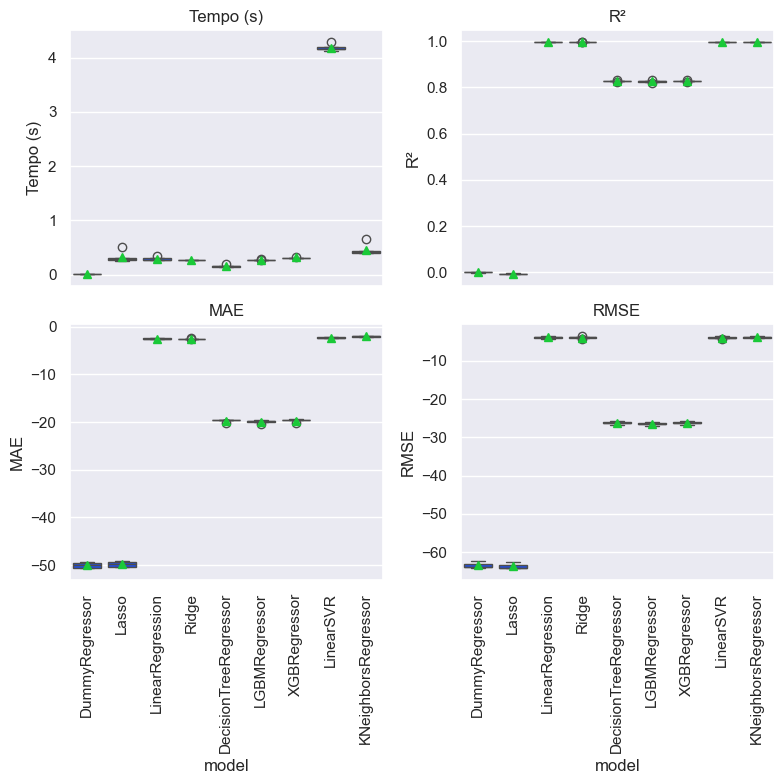

In [10]:
plot_comparar_metricas_modelos(df_resultados)

In [11]:
param_grid = {
    "regressor__reg__alpha": [0.1, 0.5, 1, 2, 5, 10]
}

In [12]:
grid_search = grid_search_cv_regressor(
    regressor=Ridge(),
    preprocessor=preprocessamento,
    target_transformer=QuantileTransformer(output_distribution="normal"),
    param_grid=param_grid,
)

grid_search

GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=TransformedTargetRegressor(regressor=Pipeline(steps=[('preprocessor',
                                                                             ColumnTransformer(transformers=[('ordinal',
                                                                                                              OrdinalEncoder(),
                                                                                                              ['tamanho_motor_l_classe',
                                                                                                               'cilindros_classe']),
                                                                                                             ('onehot',
                                                                                                              OneHotEncoder(drop='first'),
                                                                                                              ['transmissao',
                                                                                                               'tipo_combustivel',
                                                                                                               'classe_veiculo_agrupada']),
                                                                                                             (...
                                                                                                              PowerTransformer(),
                                                                                                              ['consumo_cidade_l_100km',
                                                                                                               'consumo_estrada_l_100km',
                                                                                                               'consumo_combinado_l_100km'])])),
                                                                            ('reg',
                                                                             Ridge())]),
                                                  transformer=QuantileTransformer(output_distribution='normal')),
             n_jobs=-1,
             param_grid={'regressor__reg__alpha': [0.1, 0.5, 1, 2, 5, 10]},
             refit='neg_root_mean_squared_error',
             scoring=['r2', 'neg_mean_absolute_error',
                      'neg_root_mean_squared_error'],
             verbose=1)

In [13]:
grid_search.fit(X, y)

Fitting 5 folds for each of 6 candidates, totalling 30 fits


GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=TransformedTargetRegressor(regressor=Pipeline(steps=[('preprocessor',
                                                                             ColumnTransformer(transformers=[('ordinal',
                                                                                                              OrdinalEncoder(),
                                                                                                              ['tamanho_motor_l_classe',
                                                                                                               'cilindros_classe']),
                                                                                                             ('onehot',
                                                                                                              OneHotEncoder(drop='first'),
                                                                                                              ['transmissao',
                                                                                                               'tipo_combustivel',
                                                                                                               'classe_veiculo_agrupada']),
                                                                                                             (...
                                                                                                              PowerTransformer(),
                                                                                                              ['consumo_cidade_l_100km',
                                                                                                               'consumo_estrada_l_100km',
                                                                                                               'consumo_combinado_l_100km'])])),
                                                                            ('reg',
                                                                             Ridge())]),
                                                  transformer=QuantileTransformer(output_distribution='normal')),
             n_jobs=-1,
             param_grid={'regressor__reg__alpha': [0.1, 0.5, 1, 2, 5, 10]},
             refit='neg_root_mean_squared_error',
             scoring=['r2', 'neg_mean_absolute_error',
                      'neg_root_mean_squared_error'],
             verbose=1)

In [14]:
grid_search.best_params_

{'regressor__reg__alpha': 2}

In [15]:
grid_search.best_score_

np.float64(-3.7975006700604568)

In [16]:
coefs = dataframe_coeficientes(grid_search.best_estimator_.regressor_["reg"].coef_, grid_search.best_estimator_.regressor_["preprocessor"].get_feature_names_out())

coefs

,coeficiente
onehot__tipo_combustivel_etanol,-2.104477
onehot__tipo_combustivel_gasolina_premium,-0.601745
onehot__tipo_combustivel_gasolina_regular,-0.589376
onehot__classe_veiculo_agrupada_veículo_finalidade_específica,-0.034640
onehot__classe_veiculo_agrupada_suv,-0.020268
onehot__transmissao_M,-0.010567
onehot__classe_veiculo_agrupada_picape,-0.008337
onehot__classe_veiculo_agrupada_perua,-0.008107
ordinal__cilindros_classe,-0.005149
onehot__transmissao_AS,-0.004744


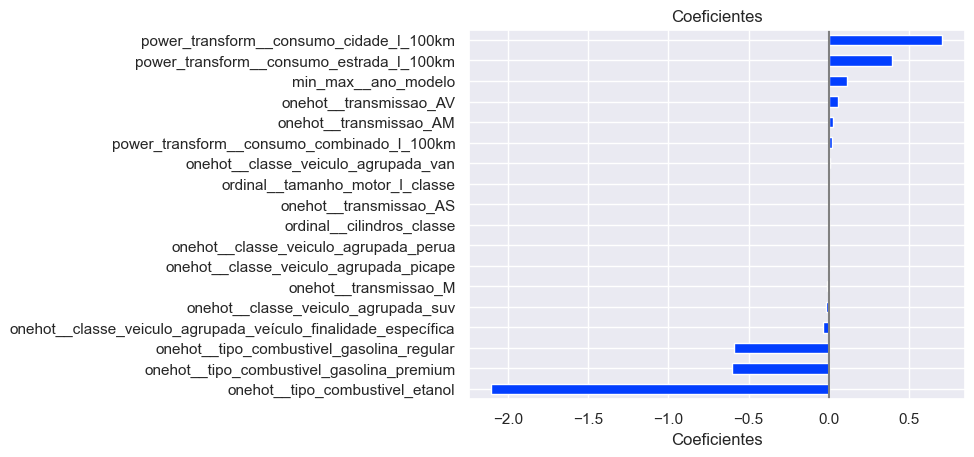

In [17]:
plot_coeficientes(coefs)

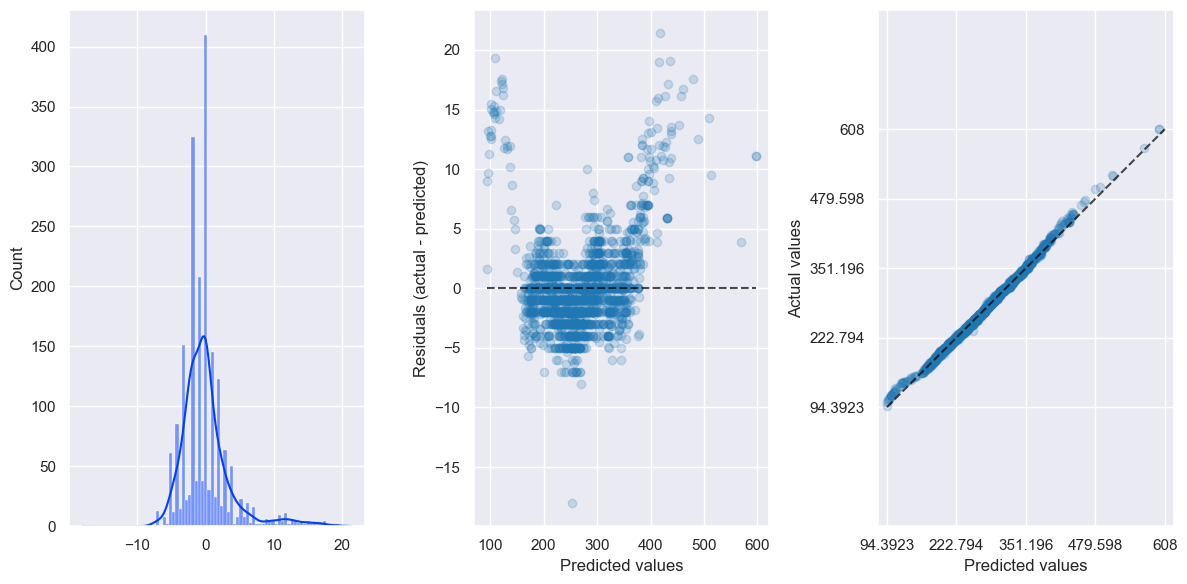

In [18]:
plot_residuos_estimador(grid_search.best_estimator_, X, y, fracao_amostra=0.1, eng_formatter=True)

In [19]:
dump(grid_search.best_estimator_, MODELO_FINAL)

['C:\\Users\\prof_\\Ciencia_de_Dados_Exercicios\\Projetos\\Projeto-emissao-co2\\dados\\ridge.joblib']